In [1]:
import numpy as np
from numpy import random as rng
from matplotlib import pyplot as plt

((1024, 2), (1024,))

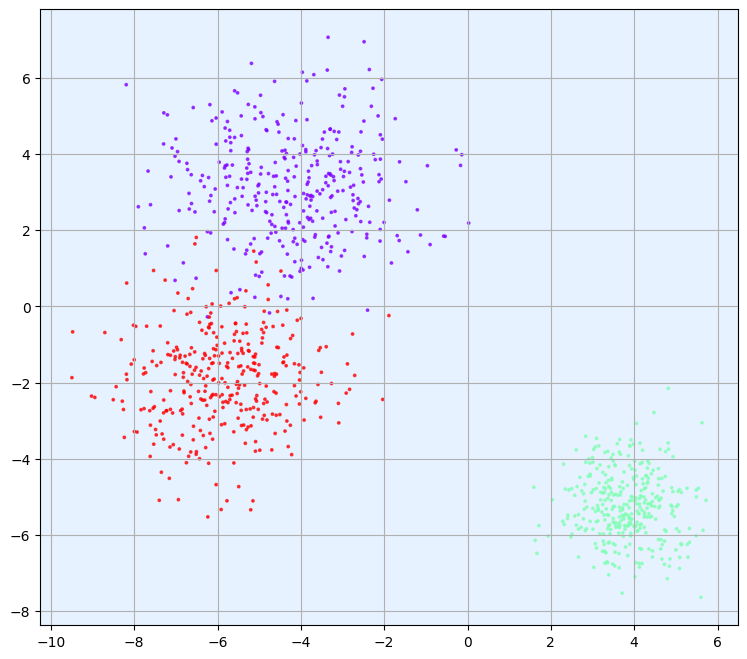

In [2]:
from sklearn.datasets import make_blobs

n_samples = 1024
n_blobs = 3 # количество кластеров

X, target = make_blobs( 
        n_samples=n_samples,
        centers=n_blobs,  
        cluster_std = rng.uniform(size=n_blobs)+.7
    )
display( (X.shape, target.shape) )

fig,ax = plt.subplots(1,figsize=(9,8))
ax.scatter(X[:,0],X[:,1],c=target, s=3,alpha=0.7,cmap='rainbow')
ax.set_facecolor('#e6f2ff')
ax.grid()
plt.show()


In [3]:
from sklearn.model_selection import train_test_split
X_train, X_test, target_train, target_test = train_test_split(X, target, test_size=0.3)
display( (X_train.shape, target_train.shape,), (X_test.shape, target_test.shape) )

((716, 2), (716,))

((308, 2), (308,))

In [4]:
# y = target.reshape(-1,1)
y_train = np.eye(target.max()+1)[target_train]
y_test = np.eye(target.max()+1)[target_test]
display( y_train.shape, y_test.shape )

(716, 3)

(308, 3)

In [5]:
from sklearn.mixture import GaussianMixture

class RBF:

    def __init__(self,n_components:int,size_out:int):
        self._gauss_mix = GaussianMixture(n_components)
        self._weight = np.zeros((n_components,size_out))

    def fit(self,x:np.ndarray,y:np.ndarray):    
        self._gauss_mix.fit(x)
        # Least Squares: W = (ΦᵀΦ)⁻¹Φᵀy
        self._weight = np.linalg.pinv( self._gauss_mix.predict_proba(x) ) @ y
        return self
    
    def predict(self,x:np.ndarray)->np.ndarray :
        return self._gauss_mix.predict_proba(x) @ self._weight

In [7]:
model = RBF(n_components=n_blobs,size_out=y_train.shape[1]).fit(X_train,y_train)
p_train = np.argmax( model.predict(X_train),axis=1)
p_test  = np.argmax( model.predict(X_test),axis=1)

In [8]:
from sklearn.metrics import classification_report

# таблица метрик качества классификации на тестовом наборе
print('train:')
print( classification_report(y_true=target_train, y_pred=p_train) )

print('----------------------\ntest:')
print( classification_report(y_true=target_test, y_pred=p_test) )

train:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       237
           1       1.00      1.00      1.00       231
           2       0.97      0.97      0.97       248

    accuracy                           0.98       716
   macro avg       0.98      0.98      0.98       716
weighted avg       0.98      0.98      0.98       716

----------------------
test:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99       105
           1       1.00      1.00      1.00       110
           2       0.98      0.99      0.98        93

    accuracy                           0.99       308
   macro avg       0.99      0.99      0.99       308
weighted avg       0.99      0.99      0.99       308



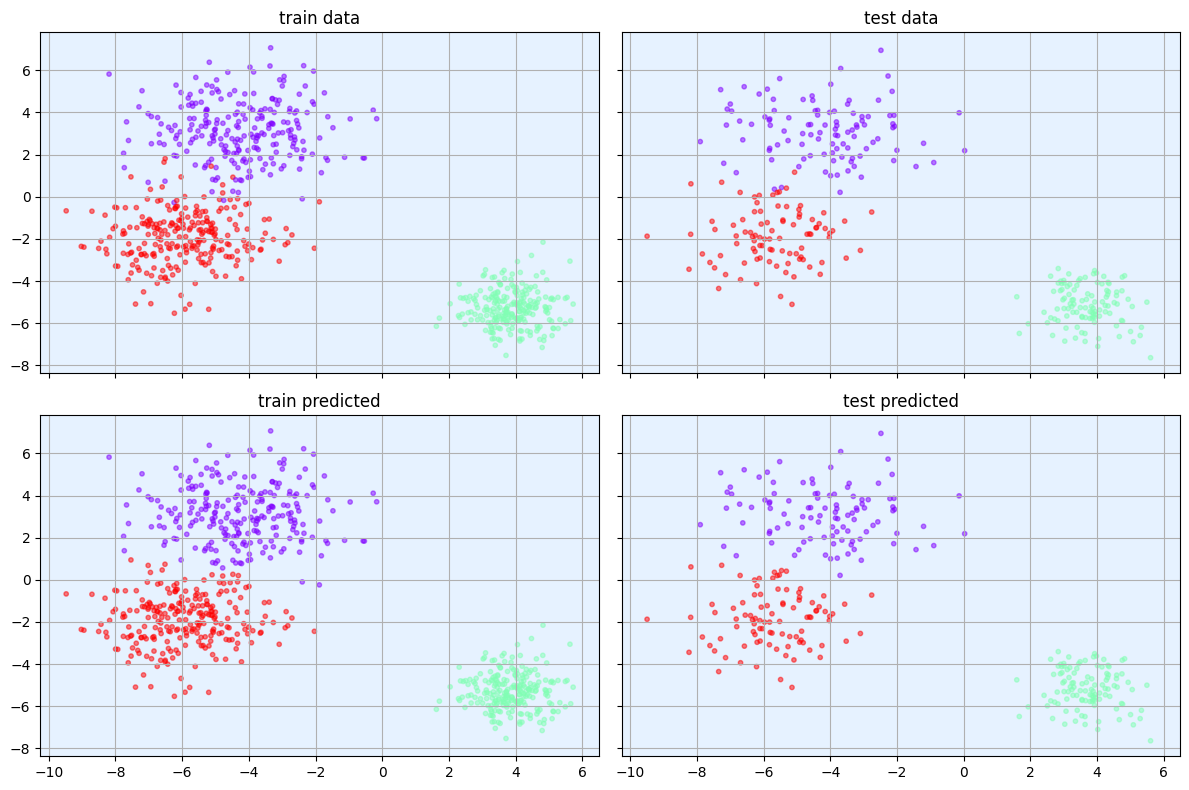

In [9]:
fig, ax = plt.subplots(2,2, sharey=True, sharex=True, figsize=(12,8),)
    
ax[0,0].scatter( x=X_train[:,0], y=X_train[:,1], c=target_train, s=10, alpha=0.5,cmap='rainbow')
ax[0,0].set_facecolor('#e6f2ff')
ax[0,0].grid()
ax[0,0].set_title('train data')

ax[0,1].scatter( x=X_test[:,0], y=X_test[:,1], c=target_test, s=10, alpha=0.5,cmap='rainbow')
ax[0,1].set_facecolor('#e6f2ff')
ax[0,1].grid()
ax[0,1].set_title('test data')

ax[1,0].scatter( x=X_train[:,0], y=X_train[:,1], c=p_train, s=10, alpha=0.5,cmap='rainbow')
ax[1,0].set_facecolor('#e6f2ff')
ax[1,0].grid()
ax[1,0].set_title('train predicted')

ax[1,1].scatter( x=X_test[:,0], y=X_test[:,1], c=p_test, s=10, alpha=0.5,cmap='rainbow')
ax[1,1].set_facecolor('#e6f2ff')
ax[1,1].grid()
ax[1,1].set_title('test predicted')

plt.tight_layout()
plt.show()